In [4]:
import pandas as pd
df = pd.read_csv("data/bitcoin_prices.csv")
print(df.head())
print(df.columns)


                    timestamp  price_usd
0  2025-05-02T00:54:17.259794      96916
1  2025-05-02T04:00:32.600525      97170
Index(['timestamp', 'price_usd'], dtype='object')


In [6]:
import os
if os.path.exists("data/bitcoin_prices.csv"):
    os.remove("data/bitcoin_prices.csv")


In [8]:
from bitcoin_utils import record_price, plot_prices
record_price("data/bitcoin_prices.csv")  # recreate file with correct columns
plot_prices("data/bitcoin_prices.csv", "Output/plot.png")


In [10]:
df = pd.read_csv("data/bitcoin_prices.csv")
print(df.columns)  # Should show ['timestamp', 'price']


Index(['timestamp', 'price'], dtype='object')


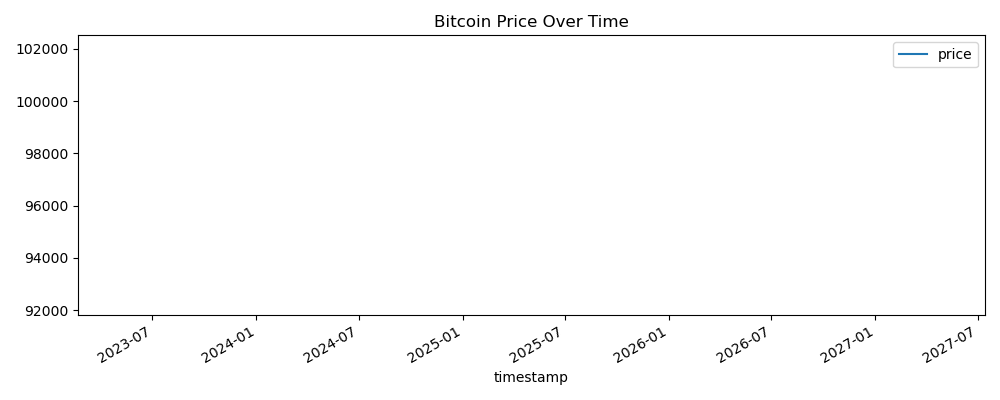

In [12]:
from IPython.display import Image, display
display(Image("Output/plot.png"))


In [14]:
def record_price(filepath="data/bitcoin_prices.csv"):
    os.makedirs("data", exist_ok=True)
    price = fetch_bitcoin_price()
    if price is None:
        print("⚠️ Price fetch failed. Skipping write.")
        return
    timestamp = datetime.datetime.utcnow().isoformat()
    df = pd.DataFrame([[timestamp, price]], columns=["timestamp", "price"])
    
    if os.path.exists(filepath):
        df.to_csv(filepath, mode='a', header=False, index=False)
    else:
        df.to_csv(filepath, index=False)
